In [1]:
# Import libraries required for feature engineering.
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
# Define the path to the cleaned historical route-level dataset.
DATA_PATH = Path(
    "../data/processed/bitre_otp_historical_route_level.csv"
)

# Load the historical route-level dataset.
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["month"],
    dtype={
        "source_sheet": "string",
    },
    low_memory=False,
)

# Display the dataset shape and date range.
print(f"Dataset shape: {df.shape}")
print(f"Earliest month: {df['month'].min()}")
print(f"Latest month:   {df['month'].max()}")

df.head()

Dataset shape: (69188, 24)
Earliest month: 2010-01-01 00:00:00
Latest month:   2026-06-01 00:00:00


,route,departing_port,arriving_port,airline,month,sectors_scheduled,sectors_flown,cancellations,departures_on_time,arrivals_on_time,...,cancellations_pct,source_sheet,is_all_airlines,is_all_ports,is_route_level,scheduled_sector_valid,departure_classification_valid,arrival_classification_valid,no_flown_sectors,missing_on_time_percentage
0,Adelaide-Alice Springs,Adelaide,Alice Springs,Qantas,2010-01-01,31.0,31.0,0.0,31.0,31.0,...,0.0,2010,False,False,True,True,True,True,False,False
1,Adelaide-Alice Springs,Adelaide,Alice Springs,Tigerair Australia,2010-01-01,13.0,13.0,0.0,11.0,11.0,...,0.0,2010,False,False,True,True,True,True,False,False
2,Adelaide-Brisbane,Adelaide,Brisbane,Jetstar,2010-01-01,30.0,30.0,0.0,22.0,23.0,...,0.0,2010,False,False,True,True,True,True,False,False
3,Adelaide-Brisbane,Adelaide,Brisbane,Qantas,2010-01-01,94.0,94.0,0.0,89.0,91.0,...,0.0,2010,False,False,True,True,True,True,False,False
4,Adelaide-Brisbane,Adelaide,Brisbane,Virgin Australia,2010-01-01,93.0,93.0,0.0,87.0,87.0,...,0.0,2010,False,False,True,True,True,True,False,False


In [3]:
# Keep observations where at least one flight was operated
# before calculating the departure delay percentage.
model_df = df[
    df["sectors_flown"] > 0
].copy()

# Calculate the monthly route-airline departure delay rate.
model_df["departure_delay_pct"] = (
    model_df["departures_delayed"]
    / model_df["sectors_flown"]
    * 100
)

# Mark observations with a sufficiently stable target.
model_df["target_volume_valid"] = (
    model_df["sectors_flown"] >= 25
)

print(f"Observations with flights: {len(model_df)}")
print(
    "Observations meeting 25-flight threshold: "
    f"{model_df['target_volume_valid'].sum()}"
)

Observations with flights: 69074
Observations meeting 25-flight threshold: 58282


In [4]:
# Sort observations chronologically within each airline and route.
model_df = model_df.sort_values(
    [
        "airline",
        "route",
        "month",
    ]
).reset_index(drop=True)

# Create calendar features that are known before the target month begins.
model_df["year"] = model_df["month"].dt.year
model_df["month_of_year"] = model_df["month"].dt.month

# Display the new calendar features.
model_df[
    [
        "airline",
        "route",
        "month",
        "year",
        "month_of_year",
        "departure_delay_pct",
    ]
].head()

,airline,route,month,year,month_of_year,departure_delay_pct
0,Bonza,Gold Coast-Melbourne,2023-11-01,2023,11,66.666667
1,Bonza,Gold Coast-Melbourne,2023-12-01,2023,12,83.333333
2,Bonza,Gold Coast-Melbourne,2024-01-01,2024,1,11.764706
3,Bonza,Gold Coast-Melbourne,2024-02-01,2024,2,0.000000
4,Bonza,Gold Coast-Melbourne,2024-03-01,2024,3,46.666667


In [5]:
# Create a lookup table containing the previous month's
# route-airline departure performance.
previous_month_df = model_df[
    [
        "airline",
        "route",
        "month",
        "departure_delay_pct",
        "cancellations_pct",
        "sectors_flown",
    ]
].copy()

# Shift the lookup month forward by one month so that
# historical values align with the following target month.
previous_month_df["month"] = (
    previous_month_df["month"]
    + pd.DateOffset(months=1)
)

# Rename historical columns to make their timing explicit.
previous_month_df = previous_month_df.rename(
    columns={
        "departure_delay_pct": "delay_pct_lag_1",
        "cancellations_pct": "cancellation_pct_lag_1",
        "sectors_flown": "sectors_flown_lag_1",
    }
)

# Attach previous-calendar-month information to each observation.
model_df = model_df.merge(
    previous_month_df,
    on=[
        "airline",
        "route",
        "month",
    ],
    how="left",
)

# Display a sample of the lagged features.
model_df[
    [
        "airline",
        "route",
        "month",
        "departure_delay_pct",
        "delay_pct_lag_1",
        "cancellation_pct_lag_1",
        "sectors_flown_lag_1",
    ]
].head(10)

,airline,route,month,departure_delay_pct,delay_pct_lag_1,cancellation_pct_lag_1,sectors_flown_lag_1
0,Bonza,Gold Coast-Melbourne,2023-11-01,66.666667,NaN,NaN,NaN
1,Bonza,Gold Coast-Melbourne,2023-12-01,83.333333,66.666667,0.000000,9.0
2,Bonza,Gold Coast-Melbourne,2024-01-01,11.764706,83.333333,57.142857,6.0
3,Bonza,Gold Coast-Melbourne,2024-02-01,0.000000,11.764706,0.000000,17.0
4,Bonza,Gold Coast-Melbourne,2024-03-01,46.666667,0.000000,11.764706,15.0
5,Bonza,Melbourne-Gold Coast,2023-11-01,33.333333,NaN,NaN,NaN
6,Bonza,Melbourne-Gold Coast,2023-12-01,83.333333,33.333333,0.000000,9.0
7,Bonza,Melbourne-Gold Coast,2024-01-01,47.058824,83.333333,57.142857,6.0
8,Bonza,Melbourne-Gold Coast,2024-02-01,26.666667,47.058824,0.000000,17.0
9,Bonza,Melbourne-Gold Coast,2024-03-01,66.666667,26.666667,11.764706,15.0


In [6]:
# Check how many observations have exact previous-month history.
print(
    "Rows with previous-month delay history: "
    f"{model_df['delay_pct_lag_1'].notna().sum()}"
)

print(
    "Rows without previous-month delay history: "
    f"{model_df['delay_pct_lag_1'].isna().sum()}"
)

Rows with previous-month delay history: 67572
Rows without previous-month delay history: 1502


In [7]:
# Create exact two-month and three-month historical features.
for lag in [2, 3]:

    # Select historical route-airline performance values.
    lag_df = model_df[
        [
            "airline",
            "route",
            "month",
            "departures_delayed",
            "cancellations",
            "sectors_flown",
            "sectors_scheduled",
        ]
    ].copy()

    # Shift the historical month forward so that each row
    # aligns with the future month that uses the lagged values.
    lag_df["month"] = (
        lag_df["month"]
        + pd.DateOffset(months=lag)
    )

    # Rename historical variables to identify the lag period.
    lag_df = lag_df.rename(
        columns={
            "departures_delayed": f"departures_delayed_lag_{lag}",
            "cancellations": f"cancellations_lag_{lag}",
            "sectors_flown": f"sectors_flown_lag_{lag}",
            "sectors_scheduled": f"sectors_scheduled_lag_{lag}",
        }
    )

    # Attach the historical values to the target observation.
    model_df = model_df.merge(
        lag_df,
        on=[
            "airline",
            "route",
            "month",
        ],
        how="left",
    )

In [8]:
# Create lag-1 count variables required for
# three-month weighted historical performance.
lag_1_counts = df[
    [
        "airline",
        "route",
        "month",
        "departures_delayed",
        "cancellations",
        "sectors_flown",
        "sectors_scheduled",
    ]
].copy()

# Keep only months where at least one flight operated.
lag_1_counts = lag_1_counts[
    lag_1_counts["sectors_flown"] > 0
].copy()

# Shift historical observations forward by one month.
lag_1_counts["month"] = (
    lag_1_counts["month"]
    + pd.DateOffset(months=1)
)

# Rename historical count variables.
lag_1_counts = lag_1_counts.rename(
    columns={
        "departures_delayed": "departures_delayed_lag_1",
        "cancellations": "cancellations_lag_1",
        "sectors_flown": "sectors_flown_count_lag_1",
        "sectors_scheduled": "sectors_scheduled_lag_1",
    }
)

# Attach lag-1 count information.
model_df = model_df.merge(
    lag_1_counts,
    on=[
        "airline",
        "route",
        "month",
    ],
    how="left",
)


In [9]:
# Calculate the total delayed departures across
# the previous three exact calendar months.
model_df["departures_delayed_previous_3m"] = (
    model_df[
        [
            "departures_delayed_lag_1",
            "departures_delayed_lag_2",
            "departures_delayed_lag_3",
        ]
    ]
    .sum(
        axis=1,
        min_count=1,
    )
)

# Calculate the total flown sectors across
# the previous three exact calendar months.
model_df["sectors_flown_previous_3m"] = (
    model_df[
        [
            "sectors_flown_count_lag_1",
            "sectors_flown_lag_2",
            "sectors_flown_lag_3",
        ]
    ]
    .sum(
        axis=1,
        min_count=1,
    )
)

# Calculate a flight-volume-weighted recent delay rate.
model_df["delay_pct_previous_3m"] = (
    model_df["departures_delayed_previous_3m"]
    / model_df["sectors_flown_previous_3m"]
    * 100
)

# Display the new historical feature.
model_df[
    [
        "airline",
        "route",
        "month",
        "departure_delay_pct",
        "delay_pct_lag_1",
        "delay_pct_previous_3m",
        "sectors_flown_previous_3m",
    ]
].head(10)

,airline,route,month,departure_delay_pct,delay_pct_lag_1,delay_pct_previous_3m,sectors_flown_previous_3m
0,Bonza,Gold Coast-Melbourne,2023-11-01,66.666667,NaN,NaN,NaN
1,Bonza,Gold Coast-Melbourne,2023-12-01,83.333333,66.666667,66.666667,9.0
2,Bonza,Gold Coast-Melbourne,2024-01-01,11.764706,83.333333,73.333333,15.0
3,Bonza,Gold Coast-Melbourne,2024-02-01,0.000000,11.764706,40.625000,32.0
4,Bonza,Gold Coast-Melbourne,2024-03-01,46.666667,0.000000,18.421053,38.0
5,Bonza,Melbourne-Gold Coast,2023-11-01,33.333333,NaN,NaN,NaN
6,Bonza,Melbourne-Gold Coast,2023-12-01,83.333333,33.333333,33.333333,9.0
7,Bonza,Melbourne-Gold Coast,2024-01-01,47.058824,83.333333,53.333333,15.0
8,Bonza,Melbourne-Gold Coast,2024-02-01,26.666667,47.058824,50.000000,32.0
9,Bonza,Melbourne-Gold Coast,2024-03-01,66.666667,26.666667,44.736842,38.0


In [10]:
# Check availability of the recent historical features.
print(
    "Rows with 1-month history: "
    f"{model_df['delay_pct_lag_1'].notna().sum()}"
)

print(
    "Rows with 3-month historical feature: "
    f"{model_df['delay_pct_previous_3m'].notna().sum()}"
)

Rows with 1-month history: 67572
Rows with 3-month historical feature: 67831


In [11]:
# Aggregate monthly performance across all routes for each airline.
airline_monthly = (
    model_df
    .groupby(
        ["airline", "month"],
        as_index=False,
    )
    .agg(
        airline_departures_delayed=("departures_delayed", "sum"),
        airline_sectors_flown=("sectors_flown", "sum"),
    )
)

# Calculate the airline's monthly departure delay rate.
airline_monthly["airline_delay_pct"] = (
    airline_monthly["airline_departures_delayed"]
    / airline_monthly["airline_sectors_flown"]
    * 100
)

# Shift airline performance forward by one month so that
# only historical information is attached to the target month.
airline_monthly["month"] = (
    airline_monthly["month"]
    + pd.DateOffset(months=1)
)

# Rename the feature to make its historical timing clear.
airline_monthly = airline_monthly.rename(
    columns={
        "airline_delay_pct": "airline_delay_pct_lag_1",
    }
)

# Attach previous-month airline performance.
model_df = model_df.merge(
    airline_monthly[
        [
            "airline",
            "month",
            "airline_delay_pct_lag_1",
        ]
    ],
    on=[
        "airline",
        "month",
    ],
    how="left",
)

In [12]:
# Aggregate monthly performance across all airlines
# operating on each directional route.
route_monthly = (
    model_df
    .groupby(
        ["route", "month"],
        as_index=False,
    )
    .agg(
        route_departures_delayed=("departures_delayed", "sum"),
        route_sectors_flown=("sectors_flown", "sum"),
    )
)

# Calculate the route's monthly departure delay rate.
route_monthly["route_delay_pct"] = (
    route_monthly["route_departures_delayed"]
    / route_monthly["route_sectors_flown"]
    * 100
)

# Shift route performance forward by one month so that
# the target month only receives historical information.
route_monthly["month"] = (
    route_monthly["month"]
    + pd.DateOffset(months=1)
)

# Rename the historical route feature.
route_monthly = route_monthly.rename(
    columns={
        "route_delay_pct": "route_delay_pct_lag_1",
    }
)

# Attach previous-month route performance.
model_df = model_df.merge(
    route_monthly[
        [
            "route",
            "month",
            "route_delay_pct_lag_1",
        ]
    ],
    on=[
        "route",
        "month",
    ],
    how="left",
)

In [13]:
# Check availability of airline-level and route-level history.
print(
    "Rows with airline previous-month history: "
    f"{model_df['airline_delay_pct_lag_1'].notna().sum()}"
)

print(
    "Rows with route previous-month history: "
    f"{model_df['route_delay_pct_lag_1'].notna().sum()}"
)

# Display a sample of the historical features.
model_df[
    [
        "airline",
        "route",
        "month",
        "departure_delay_pct",
        "delay_pct_lag_1",
        "delay_pct_previous_3m",
        "airline_delay_pct_lag_1",
        "route_delay_pct_lag_1",
    ]
].head(10)

Rows with airline previous-month history: 68706
Rows with route previous-month history: 68379


,airline,route,month,departure_delay_pct,delay_pct_lag_1,delay_pct_previous_3m,airline_delay_pct_lag_1,route_delay_pct_lag_1
0,Bonza,Gold Coast-Melbourne,2023-11-01,66.666667,NaN,NaN,NaN,37.360595
1,Bonza,Gold Coast-Melbourne,2023-12-01,83.333333,66.666667,66.666667,58.823529,45.703125
2,Bonza,Gold Coast-Melbourne,2024-01-01,11.764706,83.333333,73.333333,69.230769,49.508197
3,Bonza,Gold Coast-Melbourne,2024-02-01,0.000000,11.764706,40.625000,45.000000,36.693548
4,Bonza,Gold Coast-Melbourne,2024-03-01,46.666667,0.000000,18.421053,38.888889,31.721470
5,Bonza,Melbourne-Gold Coast,2023-11-01,33.333333,NaN,NaN,NaN,35.435993
6,Bonza,Melbourne-Gold Coast,2023-12-01,83.333333,33.333333,33.333333,58.823529,37.450980
7,Bonza,Melbourne-Gold Coast,2024-01-01,47.058824,83.333333,53.333333,69.230769,38.599349
8,Bonza,Melbourne-Gold Coast,2024-02-01,26.666667,47.058824,50.000000,45.000000,33.109017
9,Bonza,Melbourne-Gold Coast,2024-03-01,66.666667,26.666667,44.736842,38.888889,29.922780


In [14]:
# Keep observations that meet the minimum flight-volume
# threshold selected during exploratory analysis.
final_model_df = model_df[
    model_df["target_volume_valid"]
].copy()

# Sort the modelling dataset chronologically.
final_model_df = final_model_df.sort_values(
    "month"
).reset_index(drop=True)

print(
    f"Final modelling observations: "
    f"{len(final_model_df)}"
)

print(
    f"Date range: "
    f"{final_model_df['month'].min()} to "
    f"{final_model_df['month'].max()}"
)

Final modelling observations: 58282
Date range: 2010-01-01 00:00:00 to 2026-06-01 00:00:00


In [15]:
# Define candidate predictors that are available
# before the target month is completed.
feature_columns = [
    "airline",
    "route",
    "departing_port",
    "arriving_port",
    "year",
    "month_of_year",
    "delay_pct_lag_1",
    "delay_pct_previous_3m",
    "cancellation_pct_lag_1",
    "sectors_flown_lag_1",
    "airline_delay_pct_lag_1",
    "route_delay_pct_lag_1",
]

# Define the regression target.
target_column = "departure_delay_pct"

# Display the selected modelling fields.
final_model_df[
    feature_columns
    + [target_column]
].head()

,airline,route,departing_port,arriving_port,year,month_of_year,delay_pct_lag_1,delay_pct_previous_3m,cancellation_pct_lag_1,sectors_flown_lag_1,airline_delay_pct_lag_1,route_delay_pct_lag_1,departure_delay_pct
0,Jetstar,Adelaide-Brisbane,Adelaide,Brisbane,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,26.666667
1,Tigerair Australia,Hobart-Melbourne,Hobart,Melbourne,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,25.806452
2,Tigerair Australia,Gold Coast-Sydney,Gold Coast,Sydney,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,6.451613
3,Jetstar,Melbourne-Sydney,Melbourne,Sydney,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,27.210884
4,Tigerair Australia,Gold Coast-Melbourne,Gold Coast,Melbourne,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,21.782178


In [16]:
# Count missing values in each candidate model feature.
feature_missing_values = (
    final_model_df[
        feature_columns
    ]
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

print("Missing values in candidate features:")
print("-------------------------------------")
print(feature_missing_values)

Missing values in candidate features:
-------------------------------------
delay_pct_lag_1            670
cancellation_pct_lag_1     670
sectors_flown_lag_1        670
delay_pct_previous_3m      632
route_delay_pct_lag_1      457
airline_delay_pct_lag_1    319
airline                      0
route                        0
departing_port               0
arriving_port                0
year                         0
month_of_year                0
dtype: int64


In [17]:
# Define historical features required for the initial model.
required_history_features = [
    "delay_pct_lag_1",
    "delay_pct_previous_3m",
    "cancellation_pct_lag_1",
    "sectors_flown_lag_1",
    "airline_delay_pct_lag_1",
    "route_delay_pct_lag_1",
]

# Keep observations with complete historical information.
complete_model_df = final_model_df.dropna(
    subset=required_history_features
).copy()

# Calculate how many observations were removed.
rows_removed = (
    len(final_model_df)
    - len(complete_model_df)
)

print(f"Original modelling observations: {len(final_model_df)}")
print(f"Rows removed for missing history: {rows_removed}")
print(f"Complete modelling observations: {len(complete_model_df)}")

print(
    f"Data retained: "
    f"{len(complete_model_df) / len(final_model_df) * 100:.2f}%"
)

print(
    f"Date range: "
    f"{complete_model_df['month'].min()} to "
    f"{complete_model_df['month'].max()}"
)

Original modelling observations: 58282
Rows removed for missing history: 670
Complete modelling observations: 57612
Data retained: 98.85%
Date range: 2010-02-01 00:00:00 to 2026-06-01 00:00:00


In [18]:
# Confirm that all selected model features are complete.
remaining_missing_values = (
    complete_model_df[
        feature_columns
    ]
    .isna()
    .sum()
)

print("Remaining missing values:")
print("-------------------------")
print(remaining_missing_values)

print(
    "\nTotal remaining missing values: "
    f"{remaining_missing_values.sum()}"
)

Remaining missing values:
-------------------------
airline                    0
route                      0
departing_port             0
arriving_port              0
year                       0
month_of_year              0
delay_pct_lag_1            0
delay_pct_previous_3m      0
cancellation_pct_lag_1     0
sectors_flown_lag_1        0
airline_delay_pct_lag_1    0
route_delay_pct_lag_1      0
dtype: int64

Total remaining missing values: 0


In [19]:
# ---------------------------------------------------------
# Time-based dataset split
# ---------------------------------------------------------

# Use historical observations through 2023 for model training.
train_df = complete_model_df[
    complete_model_df["month"] < "2024-01-01"
].copy()

# Use 2024 as a validation period for model comparison
# and model-development decisions.
validation_df = complete_model_df[
    (complete_model_df["month"] >= "2024-01-01")
    & (complete_model_df["month"] < "2025-01-01")
].copy()

# Reserve January 2025 to June 2026 as the final
# unseen test period.
test_df = complete_model_df[
    complete_model_df["month"] >= "2025-01-01"
].copy()

# Display the size and date coverage of each split.
print("Time-based dataset split:")
print("-------------------------")

print(
    f"Training:   {len(train_df):,} rows | "
    f"{train_df['month'].min().date()} to "
    f"{train_df['month'].max().date()}"
)

print(
    f"Validation: {len(validation_df):,} rows | "
    f"{validation_df['month'].min().date()} to "
    f"{validation_df['month'].max().date()}"
)

print(
    f"Test:       {len(test_df):,} rows | "
    f"{test_df['month'].min().date()} to "
    f"{test_df['month'].max().date()}"
)

Time-based dataset split:
-------------------------
Training:   48,964 rows | 2010-02-01 to 2023-12-01
Validation: 3,556 rows | 2024-01-01 to 2024-12-01
Test:       5,092 rows | 2025-01-01 to 2026-06-01


In [20]:
# Confirm that the chronological splits do not overlap.
print(
    "Training ends before validation starts: "
    f"{train_df['month'].max() < validation_df['month'].min()}"
)

print(
    "Validation ends before test starts: "
    f"{validation_df['month'].max() < test_df['month'].min()}"
)

print(
    "Total observations across splits: "
    f"{len(train_df) + len(validation_df) + len(test_df):,}"
)

print(
    "Matches complete modelling dataset: "
    f"{len(train_df) + len(validation_df) + len(test_df) == len(complete_model_df)}"
)

Training ends before validation starts: True
Validation ends before test starts: True
Total observations across splits: 57,612
Matches complete modelling dataset: True


In [22]:
# Import regression evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [23]:
# ---------------------------------------------------------
# Persistence baseline
# ---------------------------------------------------------

# Use the previous month's route-airline delay rate
# as the prediction for the validation month.
baseline_predictions = validation_df[
    "delay_pct_lag_1"
]

# Define the actual validation target.
validation_actual = validation_df[
    "departure_delay_pct"
]

# Calculate baseline evaluation metrics.
baseline_mae = mean_absolute_error(
    validation_actual,
    baseline_predictions,
)

baseline_rmse = mean_squared_error(
    validation_actual,
    baseline_predictions,
) ** 0.5

baseline_r2 = r2_score(
    validation_actual,
    baseline_predictions,
)

print("Persistence baseline performance:")
print("---------------------------------")
print(f"MAE:  {baseline_mae:.3f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"R²:   {baseline_r2:.3f}")

Persistence baseline performance:
---------------------------------
MAE:  8.006
RMSE: 10.654
R²:   0.223


In [24]:
# Import preprocessing and modelling tools.
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [25]:
# ---------------------------------------------------------
# Define model features
# ---------------------------------------------------------

# Use categorical features that describe the airline
# and directional route.
categorical_features = [
    "airline",
    "route",
]

# Use calendar and historical performance features
# that are available before the target month.
numeric_features = [
    "year",
    "month_of_year",
    "delay_pct_lag_1",
    "delay_pct_previous_3m",
    "cancellation_pct_lag_1",
    "sectors_flown_lag_1",
    "airline_delay_pct_lag_1",
    "route_delay_pct_lag_1",
]

model_features = (
    categorical_features
    + numeric_features
)

# Create training predictors and target.
X_train = train_df[
    model_features
].copy()

y_train = train_df[
    "departure_delay_pct"
].copy()

# Create validation predictors and target.
X_validation = validation_df[
    model_features
].copy()

y_validation = validation_df[
    "departure_delay_pct"
].copy()

print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_validation):,}")

Training rows:   48,964
Validation rows: 3,556


In [26]:
# ---------------------------------------------------------
# Ridge regression model
# ---------------------------------------------------------

# One-hot encode categorical variables and standardise
# numeric variables before fitting the regression model.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features,
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
    ]
)

# Create a modelling pipeline that applies preprocessing
# before fitting Ridge Regression.
ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            Ridge(
                alpha=1.0
            ),
        ),
    ]
)

# Fit the model using historical training observations.
ridge_model.fit(
    X_train,
    y_train,
)

print("Ridge Regression training complete.")

Ridge Regression training complete.


In [27]:
# ---------------------------------------------------------
# Ridge regression validation performance
# ---------------------------------------------------------

# Generate predictions for the validation period.
ridge_predictions = ridge_model.predict(
    X_validation
)

# Calculate regression evaluation metrics.
ridge_mae = mean_absolute_error(
    y_validation,
    ridge_predictions,
)

ridge_rmse = mean_squared_error(
    y_validation,
    ridge_predictions,
) ** 0.5

ridge_r2 = r2_score(
    y_validation,
    ridge_predictions,
)

print("Ridge Regression validation performance:")
print("----------------------------------------")
print(f"MAE:  {ridge_mae:.3f}")
print(f"RMSE: {ridge_rmse:.3f}")
print(f"R²:   {ridge_r2:.3f}")

print("\nPersistence baseline:")
print("---------------------")
print(f"MAE:  {baseline_mae:.3f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"R²:   {baseline_r2:.3f}")

Ridge Regression validation performance:
----------------------------------------
MAE:  7.063
RMSE: 9.221
R²:   0.418

Persistence baseline:
---------------------
MAE:  8.006
RMSE: 10.654
R²:   0.223


In [28]:
# Import tools required for the gradient-boosting model.
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

In [31]:
# ---------------------------------------------------------
# Gradient-boosting model
# ---------------------------------------------------------

# Create a pipeline containing preprocessing
# and the gradient-boosting regression model.
gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor,
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=31,
                categorical_features=[0, 1],
                random_state=42,
            ),
        ),
    ]
)

# Fit the model using historical training observations.
gradient_boosting_model.fit(
    X_train,
    y_train,
)

print("Gradient Boosting training complete.")

Gradient Boosting training complete.


In [32]:
# Generate predictions for the 2024 validation period.
gradient_boosting_predictions = (
    gradient_boosting_model.predict(
        X_validation
    )
)

# Calculate validation metrics.
gradient_boosting_mae = mean_absolute_error(
    y_validation,
    gradient_boosting_predictions,
)

gradient_boosting_rmse = mean_squared_error(
    y_validation,
    gradient_boosting_predictions,
) ** 0.5

gradient_boosting_r2 = r2_score(
    y_validation,
    gradient_boosting_predictions,
)

print("Gradient Boosting validation performance:")
print("-----------------------------------------")
print(f"MAE:  {gradient_boosting_mae:.3f}")
print(f"RMSE: {gradient_boosting_rmse:.3f}")
print(f"R²:   {gradient_boosting_r2:.3f}")

print("\nRidge Regression:")
print("-----------------")
print(f"MAE:  {ridge_mae:.3f}")
print(f"RMSE: {ridge_rmse:.3f}")
print(f"R²:   {ridge_r2:.3f}")

print("\nPersistence baseline:")
print("---------------------")
print(f"MAE:  {baseline_mae:.3f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"R²:   {baseline_r2:.3f}")

Gradient Boosting validation performance:
-----------------------------------------
MAE:  6.943
RMSE: 8.980
R²:   0.448

Ridge Regression:
-----------------
MAE:  7.063
RMSE: 9.221
R²:   0.418

Persistence baseline:
---------------------
MAE:  8.006
RMSE: 10.654
R²:   0.223


In [33]:
# Define a small set of Gradient Boosting configurations
# for controlled validation-set comparison.
gradient_boosting_configs = [
    {
        "name": "Current",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 0.0,
    },
    {
        "name": "Smaller trees",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 20,
        "l2_regularization": 0.0,
    },
    {
        "name": "More regularized",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0,
    },
    {
        "name": "Slower learning",
        "learning_rate": 0.03,
        "max_iter": 500,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    },
]

In [34]:
# Store validation results for each model configuration.
tuning_results = []

# Train and evaluate each configuration on the same
# chronological training and validation periods.
for config in gradient_boosting_configs:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                tree_preprocessor,
            ),
            (
                "model",
                HistGradientBoostingRegressor(
                    learning_rate=config["learning_rate"],
                    max_iter=config["max_iter"],
                    max_leaf_nodes=config["max_leaf_nodes"],
                    min_samples_leaf=config["min_samples_leaf"],
                    l2_regularization=config["l2_regularization"],
                    categorical_features=[0, 1],
                    random_state=42,
                ),
            ),
        ]
    )

    # Fit using historical training observations only.
    model.fit(
        X_train,
        y_train,
    )

    # Predict the 2024 validation observations.
    predictions = model.predict(
        X_validation
    )

    # Calculate validation metrics.
    mae = mean_absolute_error(
        y_validation,
        predictions,
    )

    rmse = mean_squared_error(
        y_validation,
        predictions,
    ) ** 0.5

    r2 = r2_score(
        y_validation,
        predictions,
    )

    # Store the configuration and its performance.
    tuning_results.append(
        {
            "configuration": config["name"],
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
        }
    )

# Convert results into a DataFrame and rank by MAE.
tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values(
        "mae"
    )
    .reset_index(drop=True)
)

tuning_results_df

,configuration,mae,rmse,r2
0,More regularized,6.930868,8.958287,0.450680
1,Current,6.942866,8.980368,0.447969
2,Slower learning,6.974268,9.018190,0.443309
3,Smaller trees,6.982949,8.997698,0.445837


In [35]:
# ---------------------------------------------------------
# Final development and test datasets
# ---------------------------------------------------------

# Combine the original training and validation periods
# after model selection has been completed.
development_df = pd.concat(
    [
        train_df,
        validation_df,
    ],
    ignore_index=True,
)

# Create predictors and target for final model training.
X_development = development_df[
    model_features
].copy()

y_development = development_df[
    "departure_delay_pct"
].copy()

# Create predictors and target for the untouched test period.
X_test = test_df[
    model_features
].copy()

y_test = test_df[
    "departure_delay_pct"
].copy()

print(
    f"Development rows: {len(X_development):,}"
)

print(
    f"Test rows:        {len(X_test):,}"
)

print(
    f"Development period: "
    f"{development_df['month'].min().date()} to "
    f"{development_df['month'].max().date()}"
)

print(
    f"Test period: "
    f"{test_df['month'].min().date()} to "
    f"{test_df['month'].max().date()}"
)

Development rows: 52,520
Test rows:        5,092
Development period: 2010-02-01 to 2024-12-01
Test period: 2025-01-01 to 2026-06-01


In [36]:
# ---------------------------------------------------------
# Final Gradient Boosting model
# ---------------------------------------------------------

# Create the final model using the configuration selected
# from the 2024 validation period.
final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor,
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=31,
                min_samples_leaf=30,
                l2_regularization=1.0,
                categorical_features=[0, 1],
                random_state=42,
            ),
        ),
    ]
)

# Train the final model using all observations through 2024.
final_model.fit(
    X_development,
    y_development,
)

print("Final Gradient Boosting model training complete.")

Final Gradient Boosting model training complete.


In [37]:
# ---------------------------------------------------------
# Final test evaluation
# ---------------------------------------------------------

# Generate predictions for the untouched
# January 2025 to June 2026 test period.
final_test_predictions = final_model.predict(
    X_test
)

# Calculate final test metrics.
final_test_mae = mean_absolute_error(
    y_test,
    final_test_predictions,
)

final_test_rmse = mean_squared_error(
    y_test,
    final_test_predictions,
) ** 0.5

final_test_r2 = r2_score(
    y_test,
    final_test_predictions,
)

print("Final model test performance:")
print("-----------------------------")
print(f"MAE:  {final_test_mae:.3f}")
print(f"RMSE: {final_test_rmse:.3f}")
print(f"R²:   {final_test_r2:.3f}")

# Check the range of predictions produced by the model.
print("\nPrediction range:")
print("-----------------")
print(
    f"Minimum prediction: "
    f"{final_test_predictions.min():.2f}%"
)
print(
    f"Maximum prediction: "
    f"{final_test_predictions.max():.2f}%"
)

Final model test performance:
-----------------------------
MAE:  6.649
RMSE: 8.551
R²:   0.438

Prediction range:
-----------------
Minimum prediction: 5.59%
Maximum prediction: 62.14%


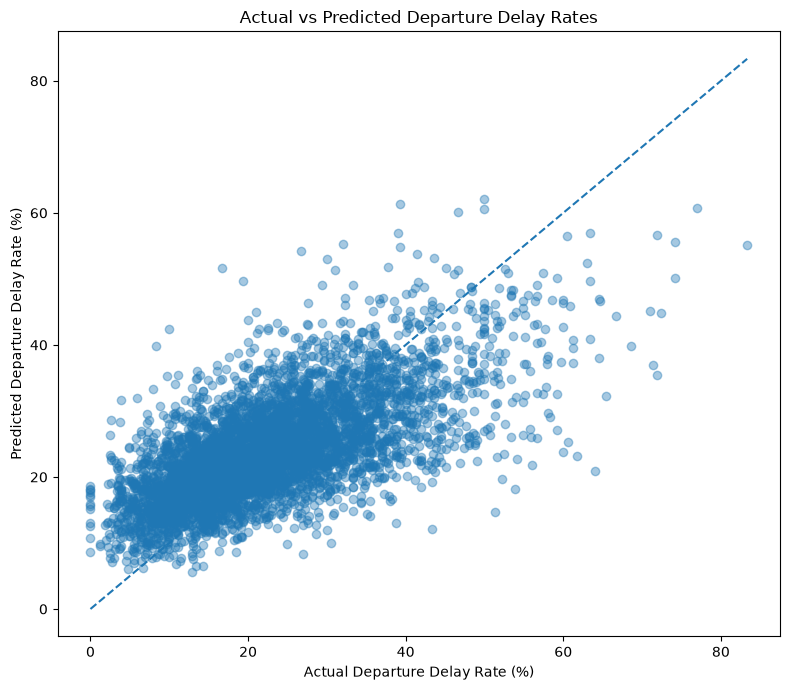

In [39]:
# Plot actual and predicted departure delay rates
# for the untouched test period.
# Import Matplotlib for model-evaluation visualisations.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    final_test_predictions,
    alpha=0.4,
)

# Add a reference line representing perfect predictions.
minimum_value = min(
    y_test.min(),
    final_test_predictions.min(),
)

maximum_value = max(
    y_test.max(),
    final_test_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.title(
    "Actual vs Predicted Departure Delay Rates"
)
plt.xlabel("Actual Departure Delay Rate (%)")
plt.ylabel("Predicted Departure Delay Rate (%)")
plt.tight_layout()
plt.show()

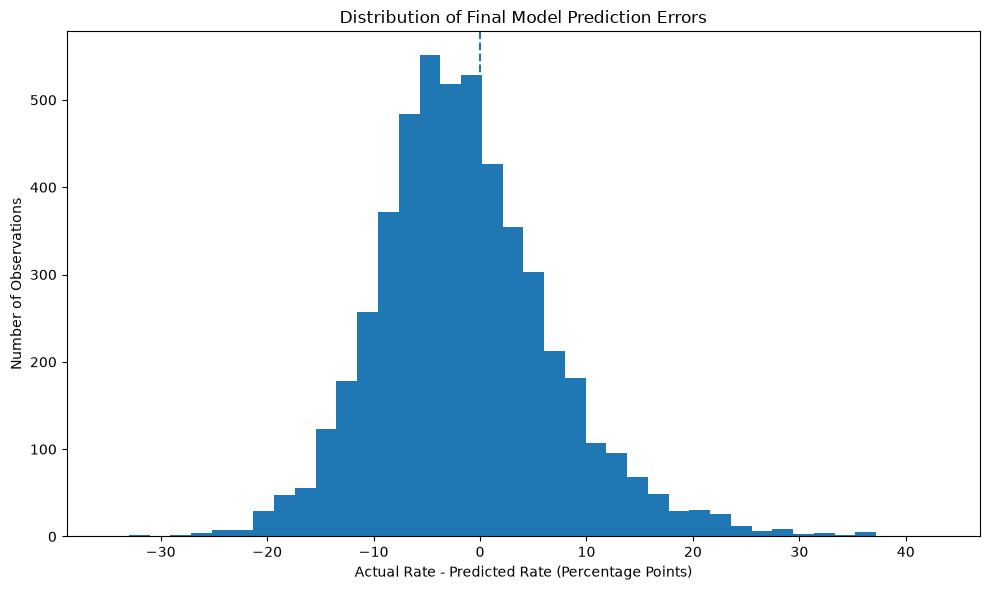

count    5092.000000
mean       -1.394843
std         8.437084
min       -34.938699
25%        -6.875519
50%        -2.107537
75%         3.278842
max        43.070794
dtype: float64

In [40]:
# Calculate prediction errors for the final test period.
# Positive residuals mean the model underpredicted the actual delay rate.
# Negative residuals mean the model overpredicted the actual delay rate.
test_residuals = (
    y_test.to_numpy()
    - final_test_predictions
)

# Plot the distribution of prediction errors.
plt.figure(figsize=(10, 6))

plt.hist(
    test_residuals,
    bins=40,
)

# Add a reference line at zero error.
plt.axvline(
    0,
    linestyle="--",
)

plt.title(
    "Distribution of Final Model Prediction Errors"
)
plt.xlabel(
    "Actual Rate - Predicted Rate (Percentage Points)"
)
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

# Display summary statistics for the prediction errors.
residual_summary = pd.Series(
    test_residuals
).describe()

residual_summary

In [41]:
# Import permutation importance for model interpretation.
from sklearn.inspection import permutation_importance

# ---------------------------------------------------------
# Permutation feature importance
# ---------------------------------------------------------

# Measure how much model performance deteriorates when
# each input feature is randomly shuffled.
permutation_results = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

# Create a table containing the average importance
# and variability across repeated permutations.
feature_importance_df = pd.DataFrame(
    {
        "feature": model_features,
        "importance": permutation_results.importances_mean,
        "importance_std": permutation_results.importances_std,
    }
)

# Rank features from most to least important.
feature_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

feature_importance_df

,feature,importance,importance_std
0,delay_pct_previous_3m,1.241791,0.014240
1,delay_pct_lag_1,1.005468,0.020532
2,month_of_year,0.700953,0.042645
3,route,0.508727,0.014728
4,airline,0.048241,0.008320
5,sectors_flown_lag_1,0.023741,0.006936
6,route_delay_pct_lag_1,0.005747,0.003883
7,year,0.000000,0.000000
8,cancellation_pct_lag_1,-0.005943,0.003848
9,airline_delay_pct_lag_1,-0.071774,0.008870


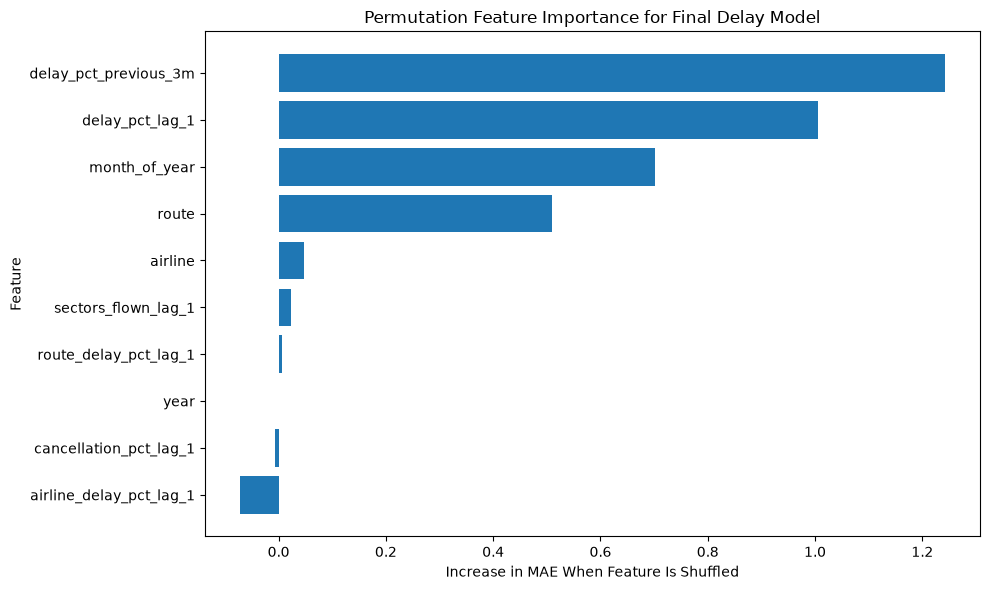

In [42]:
# Plot permutation feature importance for the final model.
plot_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=True,
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_importance_df["feature"],
    plot_importance_df["importance"],
)

plt.title(
    "Permutation Feature Importance for Final Delay Model"
)
plt.xlabel("Increase in MAE When Feature Is Shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Modelling Summary

A regression modelling approach was developed to predict the monthly departure delay percentage for each airline and directional route.

### Modelling dataset

- The target variable is `departure_delay_pct`.
- Observations with fewer than 25 sectors flown were excluded to reduce instability caused by very low monthly flight volumes.
- After requiring complete historical features, 57,612 observations were retained.
- Historical and calendar features were constructed using information available before the target month to avoid target leakage.

### Time-based validation

The data was split chronologically rather than randomly:

- Training: February 2010 to December 2023
- Validation: January 2024 to December 2024
- Test: January 2025 to June 2026

The 2025–2026 test period remained untouched during model selection.

### Model comparison

The persistence baseline, which predicts the next month's delay rate using the previous month's rate, achieved:

- MAE: 8.006 percentage points
- RMSE: 10.654 percentage points
- R²: 0.223

Ridge Regression improved performance to:

- MAE: 7.063
- RMSE: 9.221
- R²: 0.418

Gradient Boosting produced the strongest validation performance. The selected configuration used regularisation and categorical handling for airline and route.

### Final test performance

After model selection, the final Gradient Boosting model was retrained using all available development data through December 2024 and evaluated once on the unseen January 2025 to June 2026 test period.

Final test results:

- MAE: 6.649 percentage points
- RMSE: 8.551 percentage points
- R²: 0.438

The model therefore predicts monthly route-airline departure delay rates with an average absolute error of approximately 6.65 percentage points on unseen future data.

### Model interpretation

Permutation importance indicates that the strongest predictors are:

1. Previous three-month delay performance
2. Previous-month delay performance
3. Calendar month
4. Directional route

This suggests that recent operational performance, seasonality and route characteristics are important signals for forecasting future departure delay risk.

The model performs best for observations within the more common range of delay rates and tends to produce less extreme predictions when actual delay rates are unusually high or low. This is an important limitation to consider when interpreting predictions during major disruption periods.